In [193]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

## Data

SPY daily adjusted close prices from 2016–2026

In [194]:
start, end = '2016-01-01', '2026-01-01'

close_prices = yf.download('SPY', start=start, end=end, interval='1d', auto_adjust=True)['Close']
close_prices = close_prices['SPY']

print(f'Shape: {close_prices.shape}')
display(close_prices.head())

[*********************100%***********************]  1 of 1 completed

Shape: (2514,)


Date
2016-01-04    169.908127
2016-01-05    170.195557
2016-01-06    168.048615
2016-01-07    164.016907
2016-01-08    162.216599
Name: SPY, dtype: float64

## Feature Engineering

Three features derived from daily closes:

- `log_return` — raw daily directional signal
- `rolling_vol` — 20-day realized volatility
- `drawdown` — distance from 60-day rolling peak (~1 quarter)

Window parameters (`vol_window=20`, `drawdown_window=60`) follow the Guidolin & Timmermann (2007) consensus and are confirmed by BIC grid search on this dataset.

In [195]:
vol_window = 20
drawdown_window = 60

log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
rolling_vol = log_returns.rolling(window=vol_window).std()
rolling_max = close_prices.rolling(window=drawdown_window).max()
drawdowns = (close_prices - rolling_max) / close_prices

features = pd.DataFrame({
    'log_return': log_returns,
    'rolling_vol': rolling_vol,
    'drawdown': drawdowns,
}).dropna()

print(f'Shape: {features.shape}')
display(features.head())

Shape: (2455, 3)


,log_return,rolling_vol,drawdown
Date,,,
2016-03-30,0.004378,0.005590,0.000000
2016-03-31,-0.002430,0.005656,-0.002433
2016-04-01,0.006789,0.005747,0.000000
2016-04-04,-0.003243,0.005856,-0.003248
2016-04-05,-0.010038,0.006417,-0.013370


## Model

**GaussianHMM with 4 states**, fixed per Guidolin & Timmermann (2007).

BIC is unreliable for selecting `n_components` on sequential data because it assumes IID observations which HMM data violates. Domain knowledge takes precedence: the literature consistently finds 4 states map naturally to the market regimes we care about.

| Regime | Return | Vol | Drawdown |
|--------|--------|-----|----------|
| Bull | high positive | low | near zero |
| Recovery | moderate positive | moderate | mild |
| Correction | flat/negative | moderate | moderate |
| Bear | negative | high | deep |

In [196]:
def get_label_map(model_means, scaler, feature_cols) -> dict:
    """Assign regime labels by drawdown rank. Most negative drawdown = Bear."""
    regime_means = pd.DataFrame(scaler.inverse_transform(model_means), columns=feature_cols)
    sorted_labels = regime_means['drawdown'].argsort()
    return {
        sorted_labels.iloc[0]: 'Bear',
        sorted_labels.iloc[1]: 'Correction',
        sorted_labels.iloc[2]: 'Recovery',
        sorted_labels.iloc[3]: 'Bull',
    }

palette = {
    'Bull':       '#4ade80',
    'Bear':       '#f87171',
    'Recovery':   '#d0fa15',
    'Correction': '#fbbe3c',
}

In [197]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

model = GaussianHMM(n_components=4, covariance_type='full', n_iter=1000, random_state=42)
model.fit(X_scaled)

print(f'Converged: {model.monitor_.converged}')
print(f'Log-likelihood: {model.score(X_scaled):.2f}')

label_map = get_label_map(model.means_, scaler, features.columns)
regime_labels = [label_map[i] for i in range(4)]

results = features.copy()
results['regime'] = pd.Series(model.predict(X_scaled), index=features.index).map(label_map)

regime_means = pd.DataFrame(scaler.inverse_transform(model.means_), columns=features.columns, index=regime_labels)
transition_matrix = pd.DataFrame(model.transmat_, index=regime_labels, columns=regime_labels)

print(f'\nRegime counts:\n{results["regime"].value_counts()}')
print('\nRegime means:')
display(regime_means.round(4))
print('Transition matrix:')
display(transition_matrix.round(3))

Converged: True
Log-likelihood: -2606.24

Regime counts:
regime
Recovery      817
Bull          816
Correction    625
Bear          197
Name: count, dtype: int64

Regime means:


,log_return,rolling_vol,drawdown
Bull,0.0016,0.0052,-0.0017
Correction,-0.0004,0.0119,-0.0533
Recovery,0.0005,0.0079,-0.0110
Bear,-0.0007,0.0242,-0.1735


Transition matrix:


,Bull,Correction,Recovery,Bear
Bull,0.923,0.000,0.077,0.000
Correction,0.000,0.943,0.047,0.010
Recovery,0.077,0.037,0.887,0.000
Bear,0.000,0.031,0.000,0.969


## In-Sample Regime Detection

Hard labels and soft probabilities fitted on the full 2016–2026 dataset.

Regime Duration Stats (trading days)


,min,max,mean,count
regime,,,,
Bear,8,57,32.8,6
Bull,2,103,13.8,59
Correction,2,67,17.9,35
Recovery,1,43,9.3,88


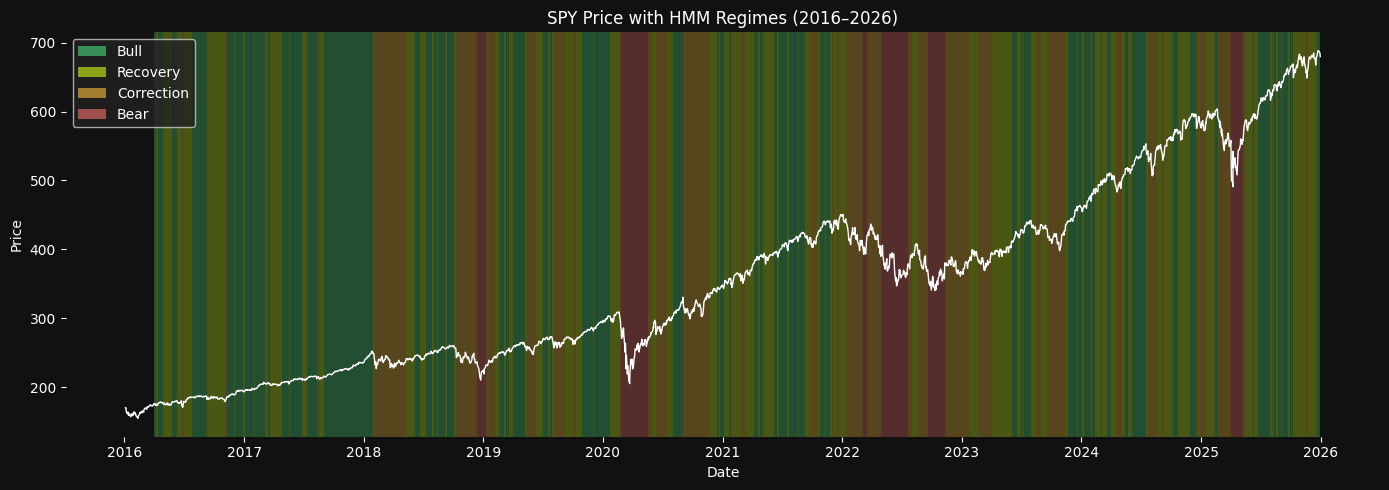

In [198]:
runs, current, count = [], results['regime'].iloc[0], 1
for label in results['regime'].iloc[1:]:
    if label == current:
        count += 1
    else:
        runs.append({'regime': current, 'duration': count})
        current, count = label, 1
runs.append({'regime': current, 'duration': count})

runs_df = pd.DataFrame(runs)
print('Regime Duration Stats (trading days)')
display(runs_df.groupby('regime')['duration'].agg(['min', 'max', 'mean', 'count']).round(1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close_prices.index, close_prices, color='white', linewidth=1, zorder=2)

current_label, start_idx = results['regime'].iloc[0], features.index[0]
for date, label in results['regime'].items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=palette[current_label], alpha=0.3, lw=0, zorder=1)
        current_label, start_idx = label, date
ax.axvspan(start_idx, features.index[-1], color=palette[current_label], alpha=0.3, lw=0, zorder=1)

legend_elements = [Patch(facecolor=palette[r], alpha=0.6, label=r) for r in ['Bull', 'Recovery', 'Correction', 'Bear']]
ax.set_title('SPY Price with HMM Regimes (2016–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(handles=legend_elements, loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()

Regime probabilities:


,Bull,Correction,Recovery,Bear
Date,,,,
2016-03-30,1.0000,0.0,0.0000,0.0
2016-03-31,0.9999,0.0,0.0001,0.0
2016-04-01,0.9992,0.0,0.0008,0.0
2016-04-04,0.9736,0.0,0.0264,0.0
2016-04-05,0.0001,0.0,0.9999,0.0


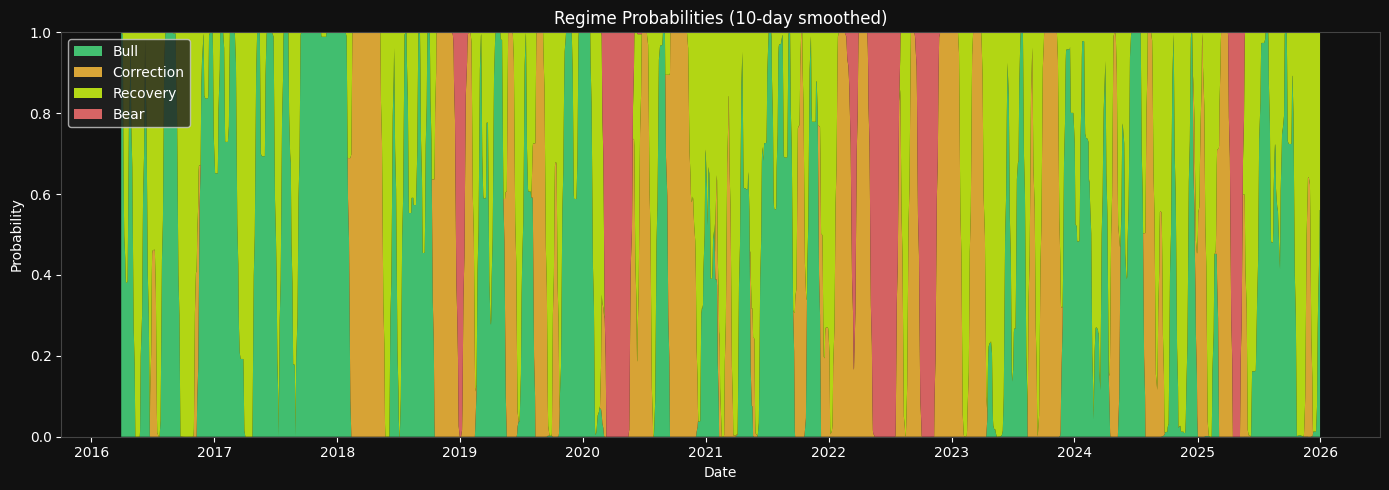

In [199]:
proba = model.predict_proba(X_scaled)
proba_df = pd.DataFrame(proba, index=features.index, columns=regime_labels)

print('Regime probabilities:')
display(proba_df.head().round(4))

# smooth for visualization only — does not affect model output
# 10-day rolling mean reduces daily noise while preserving regime structure
proba_smooth = proba_df.rolling(10, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    proba_smooth.index,
    [proba_smooth[label] for label in regime_labels],
    labels=regime_labels,
    colors=[palette[label] for label in regime_labels],
    alpha=0.85,
    edgecolor='none',
)

ax.set_ylim(0, 1)
ax.set_title('Regime Probabilities (10-day smoothed)')
ax.set_xlabel('Date')
ax.set_ylabel('Probability')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.legend(loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()

## Walk-Forward Validation

Fit on 2016-2022 data, predict on 2022–2026. 
Tests whether regimes learned before the 2022 bear market generalize to unseen data. 
The scaler is fit on training data only so no future information leaks into the test period.

Converged: True
Train log-likelihood: -772.08
Test log-likelihood:  -1686.13

Test regime counts:
Correction    384
Recovery      313
Bull          182
Bear          124
Name: count, dtype: int64


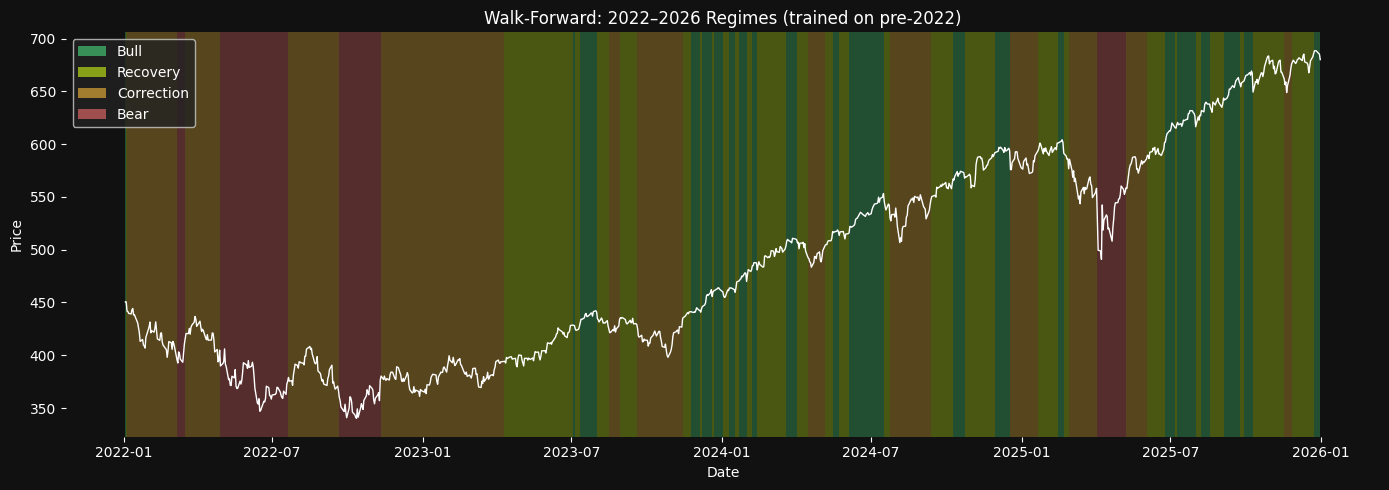

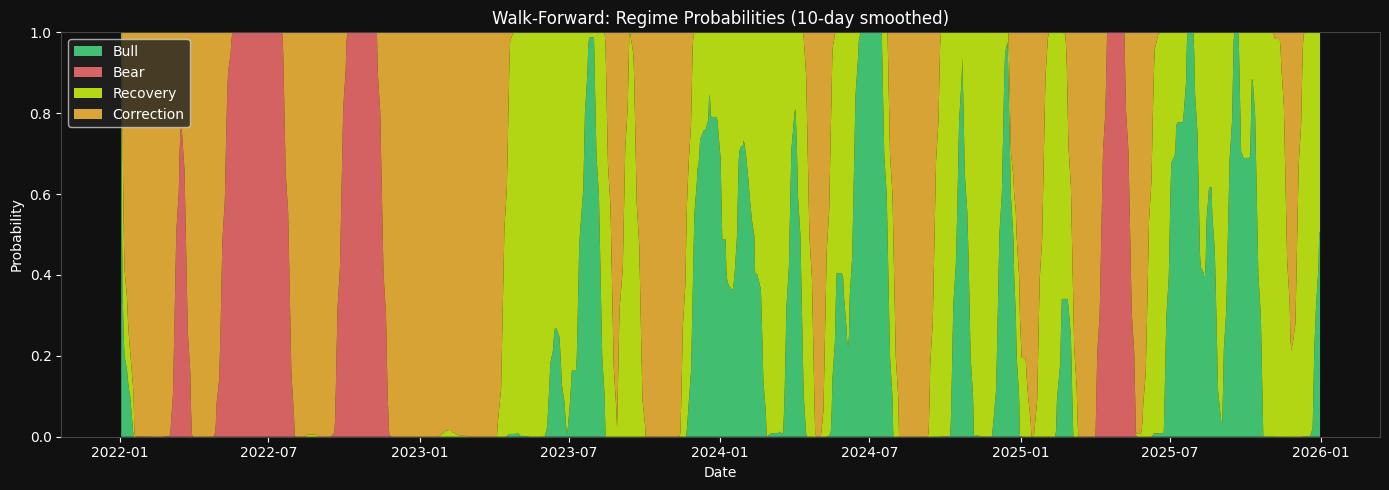

In [200]:
split_date = '2022-01-01'
feat_train = features[features.index < split_date]
feat_test  = features[features.index >= split_date]

scaler_wf = StandardScaler()
X_train = scaler_wf.fit_transform(feat_train)
X_test  = scaler_wf.transform(feat_test)

model_wf = GaussianHMM(n_components=4, covariance_type='full', n_iter=1000, random_state=42)
model_wf.fit(X_train)

print(f'Converged: {model_wf.monitor_.converged}')
print(f'Train log-likelihood: {model_wf.score(X_train):.2f}')
print(f'Test log-likelihood:  {model_wf.score(X_test):.2f}')

label_map_wf = get_label_map(model_wf.means_, scaler_wf, features.columns)
regime_labels_wf = [label_map_wf[i] for i in range(4)]
test_regimes = pd.Series(model_wf.predict(X_test), index=feat_test.index).map(label_map_wf)

print(f'\nTest regime counts:\n{test_regimes.value_counts()}')

# hard label chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close_prices.loc[feat_test.index], color='white', linewidth=1, zorder=2)

current_label, start_idx = test_regimes.iloc[0], test_regimes.index[0]
for date, label in test_regimes.items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=palette[current_label], alpha=0.3, lw=0, zorder=1)
        current_label, start_idx = label, date
ax.axvspan(start_idx, test_regimes.index[-1], color=palette[current_label], alpha=0.3, lw=0, zorder=1)

legend_elements = [Patch(facecolor=palette[r], alpha=0.6, label=r) for r in ['Bull', 'Recovery', 'Correction', 'Bear']]
ax.set_title('Walk-Forward: 2022–2026 Regimes (trained on pre-2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(handles=legend_elements, loc='upper left', facecolor='#222222', labelcolor='white')
plt.tight_layout()
plt.show()

# soft probability chart
proba_wf = model_wf.predict_proba(X_test)
proba_wf_df = pd.DataFrame(proba_wf, index=feat_test.index, columns=regime_labels_wf)
proba_wf_smooth = proba_wf_df.rolling(10, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    proba_wf_smooth.index,
    [proba_wf_smooth[label] for label in regime_labels_wf],
    labels=regime_labels_wf,
    colors=[palette[label] for label in regime_labels_wf],
    alpha=0.85,
    edgecolor='none',
)

ax.set_ylim(0, 1)
ax.set_title('Walk-Forward: Regime Probabilities (10-day smoothed)')
ax.set_xlabel('Date')
ax.set_ylabel('Probability')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.legend(loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()

## Backtest

Evaluate whether the walk-forward regime signal adds alpha over buy-and-hold on the 2022-2026 out-out-sample period

In [201]:
position_sizes = {
    'Bull':       1.0,
    'Recovery':   1.0,
    'Correction': 0.0,
    'Bear':       0.0,
}

spy_returns = close_prices[close_prices.index >= split_date].pct_change().dropna()
positions = test_regimes.map(position_sizes)
strategy_returns = (positions.shift(1) * spy_returns).dropna()

cum_strategy = (1 + strategy_returns).cumprod()
cum_benchmark = (1 + spy_returns).cumprod()

print('Regime positions:')
display(pd.DataFrame({'regime': test_regimes.head(), 'position': positions.head()}))

Regime positions:


,regime,position
Date,,
2022-01-03,Bull,1.0
2022-01-04,Recovery,1.0
2022-01-05,Correction,0.0
2022-01-06,Correction,0.0
2022-01-07,Correction,0.0


                         Strategy    Benchmark
Total Return               43.32%       50.91%
Sharpe                       1.22         0.66
Max Drawdown               -6.42%      -24.47%


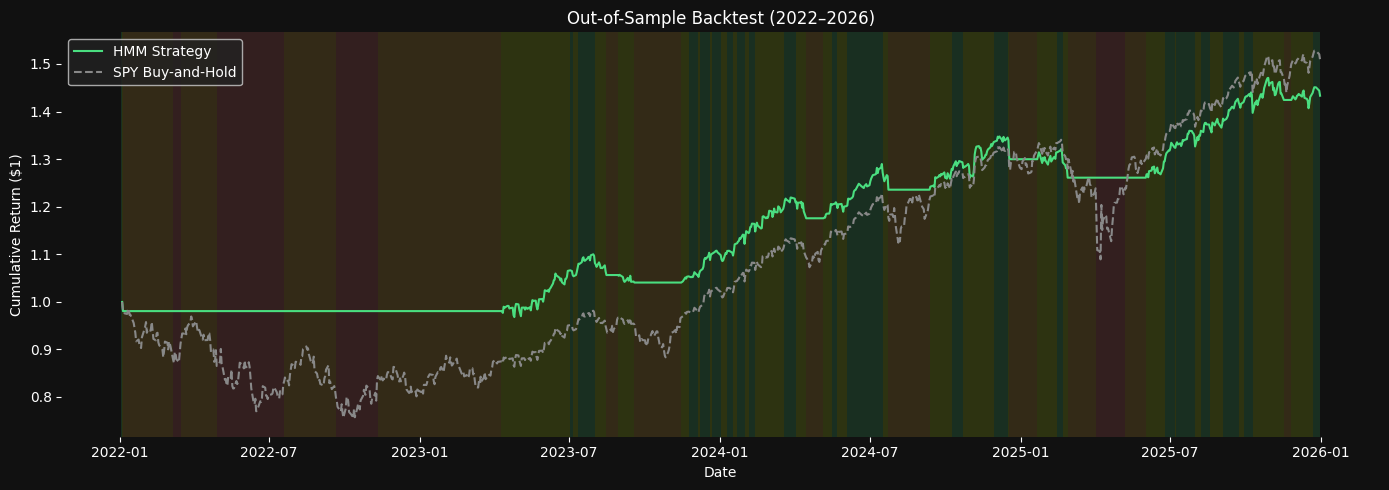

In [202]:
def sharpe(r, periods=252):
    return (r.mean() / r.std()) * np.sqrt(periods)

def max_drawdown(cum_r):
    peak = cum_r.cummax()
    return ((cum_r - peak) / peak).min()

print(f"{'':20} {'Strategy':>12} {'Benchmark':>12}")
print(f"{'Total Return':20} {cum_strategy.iloc[-1] - 1:>12.2%} {cum_benchmark.iloc[-1] - 1:>12.2%}")
print(f"{'Sharpe':20} {sharpe(strategy_returns):>12.2f} {sharpe(spy_returns):>12.2f}")
print(f"{'Max Drawdown':20} {max_drawdown(cum_strategy):>12.2%} {max_drawdown(cum_benchmark):>12.2%}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')

current_label, start_idx = test_regimes.iloc[0], test_regimes.index[0]
for date, label in test_regimes.items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=palette[current_label], alpha=0.15, lw=0)
        current_label, start_idx = label, date
ax.axvspan(start_idx, test_regimes.index[-1], color=palette[current_label], alpha=0.15, lw=0)

ax.plot(cum_strategy.index,  cum_strategy,  color='#4ade80', lw=1.5, label='HMM Strategy')
ax.plot(cum_benchmark.index, cum_benchmark, color='#888',    lw=1.5, label='SPY Buy-and-Hold', linestyle='--')

ax.set_title('Out-of-Sample Backtest (2022–2026)', color='white')
ax.set_xlabel('Date', color='white')
ax.set_ylabel('Cumulative Return ($1)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()

                      Soft Strategy  Hard Strategy    Benchmark
Total Return                 30.57%         43.32%       50.91%
Sharpe                         0.91           1.22         0.66
Max Drawdown                 -7.35%         -6.42%      -24.47%


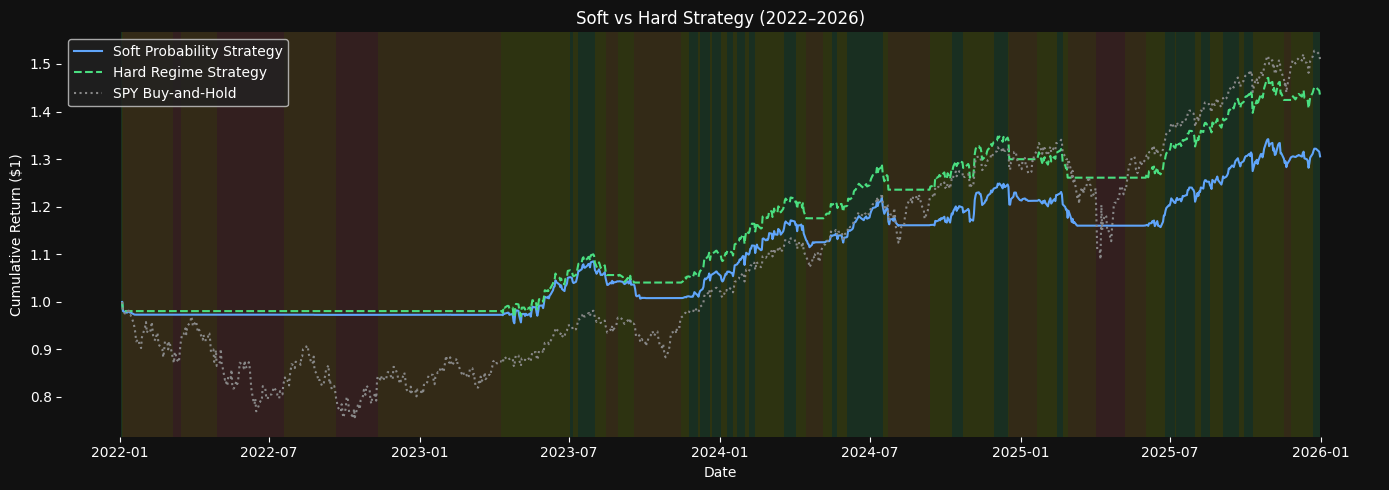

In [203]:
# continuous sizing: bullish probability = P(Bull) + P(Recovery)
bullish_prob = proba_wf_smooth['Bull'] + proba_wf_smooth['Recovery']
strategy_returns_soft = (bullish_prob.shift(1) * spy_returns).dropna()
cum_strategy_soft = (1 + strategy_returns_soft).cumprod()

print(f"{'':20} {'Soft Strategy':>14} {'Hard Strategy':>14} {'Benchmark':>12}")
print(f"{'Total Return':20} {cum_strategy_soft.iloc[-1] - 1:>14.2%} {cum_strategy.iloc[-1] - 1:>14.2%} {cum_benchmark.iloc[-1] - 1:>12.2%}")
print(f"{'Sharpe':20} {sharpe(strategy_returns_soft):>14.2f} {sharpe(strategy_returns):>14.2f} {sharpe(spy_returns):>12.2f}")
print(f"{'Max Drawdown':20} {max_drawdown(cum_strategy_soft):>14.2%} {max_drawdown(cum_strategy):>14.2%} {max_drawdown(cum_benchmark):>12.2%}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')

current_label, start_idx = test_regimes.iloc[0], test_regimes.index[0]
for date, label in test_regimes.items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=palette[current_label], alpha=0.15, lw=0)
        current_label, start_idx = label, date
ax.axvspan(start_idx, test_regimes.index[-1], color=palette[current_label], alpha=0.15, lw=0)

ax.plot(cum_strategy_soft.index, cum_strategy_soft, color='#60a5fa', lw=1.5, label='Soft Probability Strategy')
ax.plot(cum_strategy.index,      cum_strategy,      color='#4ade80', lw=1.5, label='Hard Regime Strategy', linestyle='--')
ax.plot(cum_benchmark.index,     cum_benchmark,     color='#888',    lw=1.5, label='SPY Buy-and-Hold',     linestyle=':')

ax.set_title('Soft vs Hard Strategy (2022–2026)', color='white')
ax.set_xlabel('Date', color='white')
ax.set_ylabel('Cumulative Return ($1)', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()